<a href="https://colab.research.google.com/github/zzzer0-wav/myDTA_2026/blob/main/homework/pandas_viz_practice_80_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas + Matplotlib: практикум на 80 завдань

**Рівень:** середній (pandas) + початковий (matplotlib)

---

Цей зошит містить **80 завдань**:
- **50 завдань pandas** — поглиблюємо те, що вивчили, додаємо `loc`/`iloc`, `pivot_table`, складніший `groupby`
- **30 завдань візуалізації** — pandas `.plot()` + основи matplotlib з кольорами, стилями та легендами

## Дані
Працюємо з даними стрімінгового сервісу. Два файли:

**`streaming_subscribers.csv`** (600 рядків) — підписники сервісу:

| Стовпець | Опис |
|---|---|
| `subscriber_id` | Унікальний номер підписника |
| `age` | Вік |
| `gender` | Стать (Ч / Ж) |
| `country` | Країна (Україна, Польща, Німеччина, Чехія, Литва, Іспанія) |
| `plan` | Тариф (Basic / Standard / Premium / Family) |
| `monthly_fee` | Місячна плата (грн) |
| `join_date` | Дата реєстрації |
| `is_active` | Активний абонемент (Так / Ні) |

**`streaming_sessions.csv`** (5000 рядків) — сеанси перегляду:

| Стовпець | Опис |
|---|---|
| `session_id` | Унікальний номер сеансу |
| `subscriber_id` | ID підписника (зв'язок з першою таблицею) |
| `date` | Дата перегляду |
| `genre` | Жанр |
| `device` | Пристрій (Smart TV / Laptop / Mobile / Tablet) |
| `duration_min` | Тривалість перегляду в хвилинах |
| `rating` | Оцінка користувача (1-5) |

## Як працювати
- У кожній комірці є коментар з номером завдання — пишіть код під ним
- Запускайте кожну комірку (Shift + Enter), щоб бачити результат
- Якщо забули синтаксис — користуйтесь шпаргалкою з pandas та новою шпаргалкою matplotlib
- Не бійтесь експериментувати!

---

## Підготовка

Запустіть цю комірку — вона завантажує бібліотеки та дані. Усі завдання використовують змінні `subs` (підписники) та `sess` (сеанси).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

subs = pd.read_csv("streaming_subscribers.csv")
sess = pd.read_csv("streaming_sessions.csv")

# Перетворюємо дати на справжній формат
subs["join_date"] = pd.to_datetime(subs["join_date"])
sess["date"] = pd.to_datetime(sess["date"])

print("Підписники:", subs.shape)
print("Сеанси:", sess.shape)
subs.head()

Підписники: (600, 8)
Сеанси: (5000, 7)


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так


---

# Частина 1. Pandas (50 завдань)

Розділи:
1. Розминка — повторення (1-8)
2. `loc` та `iloc` — вибірка за позиціями та мітками (9-18)
3. Складніший groupby (19-28)
4. `pivot_table` — зведені таблиці (29-36)
5. Робота з датами + обчислення (37-44)
6. Комбіновані завдання (45-50)

## Розділ 1.1. Розминка (завдання 1-8)

Швидке повторення того, що вже знаємо.

**Завдання 1.** Виведіть перші 10 рядків таблиці `sess`.

In [ ]:
# Завдання 1:
sess.head(10)

,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Анімація,Mobile,72,1
1,50017,1429,2024-06-25,Романтика,Mobile,53,5
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5
3,54446,1520,2024-07-01,Серіал,Laptop,66,3
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5
5,51938,1078,2024-08-27,Документальний,Mobile,60,4
6,52050,1343,2024-02-26,Бойовик,Tablet,86,3
7,54963,1444,2024-08-04,Серіал,Smart TV,56,4
8,50908,1521,2024-04-02,Драма,Smart TV,68,4
9,51976,1555,2024-04-11,Драма,Mobile,84,5


**Завдання 2.** Скільки всього підписників у даних? А сеансів?

> 💡 Атрибут `shape[0]` або функція `len()`.

In [ ]:
# Завдання 2:
# print(f'Усього платформа має {len(sess['subscriber_id'])} підписників')
print(f'Усього платформа має {sess.shape[0]} підписників')

Усього платформа має 5000 підписників


**Завдання 3.** Виведіть кількість підписників по кожній країні. Відсортуйте за спаданням.

> 💡 `value_counts()` вже сортує за спаданням за замовчуванням.

In [ ]:
# Завдання 3:
subs.country.value_counts()

,count
country,
Україна,256
Німеччина,101
Польща,77
Чехія,68
Іспанія,62
Литва,36


**Завдання 4.** Знайдіть середній вік підписників.

In [ ]:
# Завдання 4:
print(f'Середній вік підписників: {subs.age.mean().round(0).astype(int)} роки')

Середній вік підписників: 43 роки


**Завдання 5.** Знайдіть мінімальну та максимальну тривалість сеансу.

In [ ]:
# Завдання 5:
print(f'Мінімальна тривалість сеансу {sess.duration_min.min()} хв., та максимальна {sess.duration_min.max()} хв.')

Мінімальна тривалість сеансу 5 хв., та максимальна 171 хв.


**Завдання 6.** Скільки підписників активні (`is_active == "Так"`)?

In [ ]:
sess

,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Анімація,Mobile,72,1
1,50017,1429,2024-06-25,Романтика,Mobile,53,5
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5
3,54446,1520,2024-07-01,Серіал,Laptop,66,3
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5
...,...,...,...,...,...,...,...
4995,52398,1356,2024-08-19,Серіал,Laptop,39,4
4996,51013,1208,2024-03-17,Документальний,Laptop,79,3
4997,54579,1174,2024-05-25,Анімація,Laptop,46,4
4998,52743,1431,2024-07-23,Романтика,Mobile,43,4


In [ ]:
# Завдання 6:
print(f'Зараз {(subs.is_active == 'Так').sum()} активних користувачів')

Зараз 447 активних користувачів


**Завдання 7.** Виведіть тільки сеанси з жанром `Драма` та оцінкою 5.

> 💡 Дві умови через `&`, кожна в дужках.

In [ ]:
# Завдання 7:
print('Фільми жанра "Драма" з рейтингом 5')
sess[(sess['genre']=='Драма') & (sess['rating']==5)]


Фільми жанра "Драма" з рейтингом 5


,session_id,subscriber_id,date,genre,device,duration_min,rating
9,51976,1555,2024-04-11,Драма,Mobile,84,5
68,51372,1447,2024-06-19,Драма,Tablet,93,5
74,53138,1074,2024-01-05,Драма,Laptop,48,5
94,52201,1124,2024-06-17,Драма,Laptop,34,5
117,53459,1454,2024-05-04,Драма,Mobile,77,5
...,...,...,...,...,...,...,...
4852,52566,1345,2024-03-28,Драма,Laptop,43,5
4855,51811,1579,2024-04-04,Драма,Smart TV,99,5
4902,53655,1551,2024-06-30,Драма,Laptop,48,5
4939,50494,1468,2024-01-30,Драма,Smart TV,36,5


**Завдання 8.** Створіть у таблиці `subs` новий стовпець `annual_fee` = `monthly_fee` × 12.

In [ ]:
# Завдання 8:
subs['annual_fee'] = subs['monthly_fee'] * 12
subs

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні,3948
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так,2628
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так,1788
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так,1788
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так,2628
...,...,...,...,...,...,...,...,...,...
595,1596,53,Ж,Україна,Premium,329,2022-04-15,Так,3948
596,1597,30,Ч,Україна,Family,449,2024-03-26,Так,5388
597,1598,38,Ч,Німеччина,Family,449,2024-06-12,Так,5388
598,1599,64,Ж,Чехія,Standard,219,2024-05-03,Ні,2628


## Розділ 1.2. loc та iloc (завдання 9-18)

`iloc` працює за **числовими позиціями** (як індекси у списку):
- `df.iloc[0]` — перший рядок
- `df.iloc[0:5]` — рядки 0-4
- `df.iloc[0, 2]` — рядок 0, стовпець 2
- `df.iloc[:, 1:3]` — усі рядки, стовпці 1-2

`loc` працює за **мітками** (назвами):
- `df.loc[0]` — рядок з міткою 0
- `df.loc[df["age"] > 30, "country"]` — фільтр + конкретний стовпець
- `df.loc[df["plan"] == "Premium", ["age", "country"]]` — фільтр + кілька стовпців

**Завдання 9.** Виведіть перший рядок таблиці `subs` за допомогою `iloc`.

> 💡 `subs.iloc[0]`.

In [ ]:
# Завдання 9:
subs.iloc[0]

,0
subscriber_id,1001
age,19
gender,Ч
country,Україна
plan,Premium
monthly_fee,329
join_date,2023-02-27 00:00:00
is_active,Ні
annual_fee,3948


**Завдання 10.** Виведіть рядки з 10 по 15 (включно) таблиці `subs` за допомогою `iloc`.

> 💡 `iloc[10:16]` (правий кінець не включається).

In [ ]:
# Завдання 10:
subs.iloc[5:16]

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
5,1006,37,Ж,Польща,Standard,219,2024-11-17,Так,2628
6,1007,16,Ж,Україна,Premium,329,2024-07-22,Так,3948
7,1008,49,Ч,Німеччина,Standard,219,2022-11-06,Так,2628
8,1009,47,Ж,Німеччина,Basic,149,2023-09-13,Ні,1788
9,1010,40,Ж,Німеччина,Standard,219,2022-10-03,Ні,2628
10,1011,16,Ч,Іспанія,Family,449,2023-09-17,Так,5388
11,1012,56,Ч,Україна,Standard,219,2024-12-08,Так,2628
12,1013,25,Ч,Іспанія,Standard,219,2023-01-01,Так,2628
13,1014,17,Ч,Україна,Standard,219,2023-07-21,Так,2628
14,1015,55,Ж,Україна,Standard,219,2022-02-14,Ні,2628


**Завдання 11.** Виведіть значення з 5-го рядка, 3-го стовпця таблиці `subs`.

> 💡 `iloc[5, 3]`. Нумерація з нуля!

In [ ]:
# Завдання 11:
subs.iloc[5, 2]

'Ж'

**Завдання 12.** Виведіть перші 3 стовпці таблиці `sess` (усі рядки) за допомогою `iloc`.

> 💡 `iloc[:, :3]`.

In [ ]:
# Завдання 12:
sess.iloc[:, :3]

,session_id,subscriber_id,date
0,51573,1166,2024-04-11
1,50017,1429,2024-06-25
2,50861,1404,2024-07-05
3,54446,1520,2024-07-01
4,51561,1052,2024-06-13
...,...,...,...
4995,52398,1356,2024-08-19
4996,51013,1208,2024-03-17
4997,54579,1174,2024-05-25
4998,52743,1431,2024-07-23


**Завдання 13.** Виведіть рядки 100-104, тільки стовпці `age` та `country`. Використайте `iloc`.

> 💡 `iloc[100:105, [1, 3]]` — індекси стовпців: age=1, country=3.

In [ ]:
# Завдання 13:
subs.iloc[100:105, [1, 3]]

,age,country
100,63,Польща
101,21,Німеччина
102,62,Польща
103,48,Україна
104,54,Україна


**Завдання 14.** За допомогою `loc` виведіть тільки тих підписників, у яких вік більше 50. Поверніть тільки стовпці `country` та `plan`.

> 💡 `subs.loc[subs["age"] > 50, ["country", "plan"]]`.

In [ ]:
# Завдання 14:
subs.loc[subs['age']>50, ['country', 'plan']]

,country,plan
2,Україна,Basic
11,Україна,Standard
14,Україна,Standard
16,Німеччина,Standard
18,Польща,Standard
...,...,...
593,Іспанія,Basic
594,Україна,Basic
595,Україна,Premium
598,Чехія,Standard


**Завдання 15.** За допомогою `loc` виведіть стовпець `monthly_fee` тільки для активних підписників (`is_active == "Так"`).

In [ ]:
# Завдання 15:
subs.loc[subs['is_active']=='Так', ['monthly_fee']]

,monthly_fee
1,219
2,149
3,149
4,219
5,219
...,...
594,149
595,329
596,449
597,449


**Завдання 16.** Знайдіть середній вік підписників з тарифом `Premium`, використовуючи `loc`.

> 💡 `subs.loc[subs["plan"]=="Premium", "age"].mean()`.

In [ ]:
# Завдання 16:
subs.loc[subs['plan']=='Premium', ['age']].mean().round(2)

,0
age,42.29


**Завдання 17.** Використовуючи `loc`, ЗМІНІТЬ значення `is_active` на `"Так"` для підписника з `subscriber_id == 1001`.

> 💡 `subs.loc[subs["subscriber_id"]==1001, "is_active"] = "Так"`. Потім перевірте результат.

In [ ]:
# Завдання 17:
subs.loc[subs['subscriber_id']==1001, 'is_active'] = 'Так'
subs.loc[subs['subscriber_id'] == 1001]

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Так,3948


**Завдання 18.** Виведіть останні 5 рядків таблиці `subs` за допомогою `iloc` (без `tail`).

> 💡 Від'ємні індекси: `iloc[-5:]`.

In [ ]:
# Завдання 18:
subs.iloc[-5:]

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
595,1596,53,Ж,Україна,Premium,329,2022-04-15,Так,3948
596,1597,30,Ч,Україна,Family,449,2024-03-26,Так,5388
597,1598,38,Ч,Німеччина,Family,449,2024-06-12,Так,5388
598,1599,64,Ж,Чехія,Standard,219,2024-05-03,Ні,2628
599,1600,68,Ч,Польща,Standard,219,2022-07-28,Так,2628


## Розділ 1.3. Складніший groupby (завдання 19-28)

Нові можливості:
- `.agg(["sum", "mean", "count"])` — кілька агрегатів одразу
- `.agg({"col1": "mean", "col2": "sum"})` — різні агрегати на різні стовпці
- `.transform("mean")` — повертає те саме число для кожного рядка групи (зручно для нових стовпців)
- `groupby(["col1", "col2"])` — групування за кількома стовпцями
- `.size()` — кількість рядків у кожній групі

**Завдання 19.** Для кожної країни виведіть кількість підписників та середній вік за один виклик `agg`.

> 💡 `subs.groupby("country").agg({"subscriber_id": "count", "age": "mean"})`.

In [ ]:
# Завдання 19:
subs.groupby('country').agg({'subscriber_id':'count', 'age':'mean'}).round(0)

,subscriber_id,age
country,,
Іспанія,62,43.0
Литва,36,40.0
Німеччина,101,45.0
Польща,77,43.0
Україна,256,44.0
Чехія,68,41.0


**Завдання 20.** Для кожного тарифу (`plan`) виведіть мінімальний, середній і максимальний вік підписників.

> 💡 `agg(["min", "mean", "max"])` на стовпці `age`.

In [ ]:
# Завдання 20:
subs.groupby('plan')['age'].agg(['min', 'mean', 'max']).round(2)

,min,mean,max
plan,,,
Basic,16,44.52,70
Family,16,41.93,70
Premium,16,42.29,70
Standard,16,43.38,70


**Завдання 21.** Для кожного жанру в таблиці `sess` порахуйте кількість сеансів та середню тривалість.

> 💡 `sess.groupby("genre").agg({"session_id": "count", "duration_min": "mean"})`.

In [ ]:
# Завдання 21:
sess.groupby('genre').agg({'session_id':'count', 'duration_min':'mean'}).round(2)

,session_id,duration_min
genre,,
Анімація,653,53.43
Бойовик,661,52.86
Документальний,573,52.66
Драма,578,52.86
Жахи,631,52.24
Комедія,629,54.13
Романтика,644,54.71
Серіал,631,53.95


**Завдання 22.** Для кожного пристрою порахуйте середню оцінку (`rating`) та середню тривалість (`duration_min`).

In [ ]:
sess

,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Анімація,Mobile,72,1
1,50017,1429,2024-06-25,Романтика,Mobile,53,5
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5
3,54446,1520,2024-07-01,Серіал,Laptop,66,3
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5
...,...,...,...,...,...,...,...
4995,52398,1356,2024-08-19,Серіал,Laptop,39,4
4996,51013,1208,2024-03-17,Документальний,Laptop,79,3
4997,54579,1174,2024-05-25,Анімація,Laptop,46,4
4998,52743,1431,2024-07-23,Романтика,Mobile,43,4


In [ ]:
# Завдання 22:
sess.groupby('device')[['rating', 'duration_min']].mean().round(2)

,rating,duration_min
device,,
Laptop,3.98,52.85
Mobile,3.99,52.83
Smart TV,4.05,53.61
Tablet,4.01,55.38


**Завдання 23.** Згрупуйте сеанси за двома стовпцями: `genre` та `device`. Порахуйте середню оцінку.

> 💡 `groupby(["genre", "device"])["rating"].mean()`.

In [ ]:
# Завдання 23:
sess.groupby(['genre', 'device'])['rating'].mean().round(2).unstack()

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,3.91,4.07,4.01,3.88
Бойовик,4.08,3.81,3.91,4.07
Документальний,4.03,4.00,4.12,3.98
Драма,3.97,4.11,4.11,4.20
Жахи,3.96,3.99,4.08,4.14
Комедія,3.99,4.02,4.02,3.97
Романтика,4.00,3.92,4.09,4.09
Серіал,3.94,4.05,4.10,3.72


**Завдання 24.** Скільки сеансів припадає на кожну пару (`genre`, `device`)? Використайте `.size()`.

In [ ]:
# Завдання 24:
sess.groupby(['genre', 'device']).size()

genre           device  
Анімація        Laptop      185
                Mobile      166
                Smart TV    227
                Tablet       75
Бойовик         Laptop      193
                Mobile      175
                Smart TV    223
                Tablet       70
Документальний  Laptop      175
                Mobile      136
                Smart TV    214
                Tablet       48
Драма           Laptop      154
                Mobile      158
                Smart TV    207
                Tablet       59
Жахи            Laptop      180
                Mobile      162
                Smart TV    210
                Tablet       79
Комедія         Laptop      184
                Mobile      154
                Smart TV    233
                Tablet       58
Романтика       Laptop      203
                Mobile      166
                Smart TV    217
                Tablet       58
Серіал          Laptop      185
                Mobile      166
                Smart TV    220
                Tablet       60
dtype: int64

**Завдання 25.** Додайте до таблиці `sess` новий стовпець `avg_rating_genre` — середня оцінка по жанру для цього сеансу. Використайте `.transform("mean")`.

> 💡 `sess["avg_rating_genre"] = sess.groupby("genre")["rating"].transform("mean")`.

In [ ]:
# Завдання 25:
sess['avg_rating_genre'] = sess.groupby('genre')['rating'].transform('mean').round(2)
sess

,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre
0,51573,1166,2024-04-11,Анімація,Mobile,72,1,3.98
1,50017,1429,2024-06-25,Романтика,Mobile,53,5,4.02
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5,3.95
3,54446,1520,2024-07-01,Серіал,Laptop,66,3,4.00
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5,3.95
...,...,...,...,...,...,...,...,...
4995,52398,1356,2024-08-19,Серіал,Laptop,39,4,4.00
4996,51013,1208,2024-03-17,Документальний,Laptop,79,3,4.05
4997,54579,1174,2024-05-25,Анімація,Laptop,46,4,3.98
4998,52743,1431,2024-07-23,Романтика,Mobile,43,4,4.02


**Завдання 26.** Додайте до таблиці `subs` стовпець `avg_age_country` — середній вік підписників у країні цього підписника.

In [ ]:
# Завдання 26:
subs['avg_age_country'] = subs.groupby('country')['age'].transform('mean').astype(int)
subs

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee,avg_age_country
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Так,3948,43
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так,2628,42
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так,1788,43
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так,1788,40
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так,2628,43
...,...,...,...,...,...,...,...,...,...,...
595,1596,53,Ж,Україна,Premium,329,2022-04-15,Так,3948,43
596,1597,30,Ч,Україна,Family,449,2024-03-26,Так,5388,43
597,1598,38,Ч,Німеччина,Family,449,2024-06-12,Так,5388,45
598,1599,64,Ж,Чехія,Standard,219,2024-05-03,Ні,2628,40


**Завдання 27.** Знайдіть країну з найбільшим середнім віком підписників.

> 💡 `groupby + mean + idxmax()` АБО `sort_values(ascending=False).head(1)`.

In [ ]:
# Завдання 27:
subs.groupby('country')['age'].mean().sort_values(ascending=False).head(1)
# subs.groupby('country')['age'].mean().idxmax()

,age
country,
Німеччина,45.09901


**Завдання 28.** Для кожної країни порахуйте, скільки активних і скільки неактивних підписників. Використайте `groupby` за двома стовпцями + `size()`.

> 💡 `subs.groupby(["country", "is_active"]).size()`.

In [ ]:
# Завдання 28:
subs.groupby(['country', 'is_active']).size()

country    is_active
Іспанія    Ні            16
           Так           46
Литва      Ні             7
           Так           29
Німеччина  Ні            29
           Так           72
Польща     Ні            21
           Так           56
Україна    Ні            66
           Так          190
Чехія      Ні            13
           Так           55
dtype: int64

## Розділ 1.4. pivot_table — зведені таблиці (завдання 29-36)

`pivot_table` створює таблицю, де:
- `index` — що ставимо у рядки
- `columns` — що ставимо у стовпці
- `values` — що рахуємо
- `aggfunc` — який агрегат (за замовч. `"mean"`)

Приклад:
```python
pd.pivot_table(df, index="country", columns="plan", values="age", aggfunc="mean")
```


**Завдання 29.** Створіть зведену таблицю: рядки — `country`, стовпці — `plan`, значення — кількість підписників.

> 💡 `aggfunc="count"`, як `values` можна взяти `subscriber_id`.

In [ ]:
# Завдання 29:
subs.pivot_table(
    index='country',
    columns='plan',
    values='subscriber_id',
    aggfunc='count'
)

plan,Basic,Family,Premium,Standard
country,,,,
Іспанія,18,9,13,22
Литва,5,7,10,14
Німеччина,24,17,19,41
Польща,10,9,23,35
Україна,68,34,60,94
Чехія,13,16,16,23


**Завдання 30.** Зведена таблиця: рядки — `country`, стовпці — `plan`, значення — середній вік.

> 💡 `aggfunc="mean"` (за замовчуванням).

In [ ]:
# Завдання 30:
subs.pivot_table(
    index='country',
    columns='plan',
    values='age',
).astype(int)

plan,Basic,Family,Premium,Standard
country,,,,
Іспанія,42,38,45,43
Литва,39,42,37,41
Німеччина,46,46,42,44
Польща,45,40,38,45
Україна,45,41,44,42
Чехія,41,40,38,41


**Завдання 31.** Зведена таблиця по сеансах: рядки — `genre`, стовпці — `device`, значення — середня оцінка.

In [ ]:
# Завдання 31:
sess.pivot_table(
    index='genre',
    columns='device',
    values='rating'
).round(2)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,3.91,4.07,4.01,3.88
Бойовик,4.08,3.81,3.91,4.07
Документальний,4.03,4.00,4.12,3.98
Драма,3.97,4.11,4.11,4.20
Жахи,3.96,3.99,4.08,4.14
Комедія,3.99,4.02,4.02,3.97
Романтика,4.00,3.92,4.09,4.09
Серіал,3.94,4.05,4.10,3.72


**Завдання 32.** Зведена таблиця: рядки — `genre`, стовпці — `device`, значення — сумарна тривалість сеансів.

> 💡 `aggfunc="sum"`.

In [ ]:
# Завдання 32:
sess.pivot_table(
    index='genre',
    columns='device',
    values='duration_min',
    aggfunc='sum'
)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,9358,8700,12457,4375
Бойовик,10023,9625,11471,3819
Документальний,9116,6731,11690,2636
Драма,8050,8391,10806,3307
Жахи,9479,8513,11095,3877
Комедія,10208,8427,12034,3376
Романтика,10659,8610,12685,3280
Серіал,10221,8778,11640,3406


**Завдання 33.** Зведена таблиця: рядки — `country`, стовпці — `gender`, значення — кількість підписників.

In [ ]:
# Завдання 33:
subs.pivot_table(
    index='country',
    columns='gender',
    values='subscriber_id',
    aggfunc='count'
)

gender,Ж,Ч
country,,
Іспанія,32,30
Литва,22,14
Німеччина,51,50
Польща,40,37
Україна,132,124
Чехія,36,32


**Завдання 34.** Зведена таблиця: рядки — `plan`, стовпці — `is_active`, значення — кількість підписників.

In [ ]:
# Завдання 34:
subs.pivot_table(
    index='plan',
    columns='is_active',
    values='subscriber_id',
    aggfunc='count'
)

is_active,Ні,Так
plan,,
Basic,35,103
Family,26,66
Premium,41,100
Standard,50,179


**Завдання 35.** Створіть зведену таблицю по сеансах: `genre` у рядках, `device` у стовпцях, кількість сеансів. Заповніть пропуски нулями.

> 💡 Параметр `fill_value=0`.

In [ ]:
# Завдання 35:
sess.pivot_table(
    index='genre',
    columns='device',
    values='session_id',
    aggfunc='count',
    fill_value=0
)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,185,166,227,75
Бойовик,193,175,223,70
Документальний,175,136,214,48
Драма,154,158,207,59
Жахи,180,162,210,79
Комедія,184,154,233,58
Романтика,203,166,217,58
Серіал,185,166,220,60


**Завдання 36.** Зведена таблиця: рядки — `country`, значення — кількість підписників та середній `monthly_fee` одночасно.

> 💡 `values=["subscriber_id", "monthly_fee"]` плюс `aggfunc={"subscriber_id":"count", "monthly_fee":"mean"}`.

In [ ]:
# Завдання 36:
subs.pivot_table(
    index='country',
    values=['subscriber_id', 'monthly_fee'],
    aggfunc={'subscriber_id':'count', 'monthly_fee':'mean'}
).round(2)

,monthly_fee,subscriber_id
country,,
Іспанія,255.13,62
Литва,284.56,36
Німеччина,261.77,101
Польща,269.65,77
Україна,256.73,256
Чехія,285.62,68


## Розділ 1.5. Робота з датами + обчислення (завдання 37-44)

Нагадування: дати вже перетворено на datetime у комірці підготовки.
- `.dt.year`, `.dt.month`, `.dt.day` — частини дати
- `.dt.day_name()` — назва дня тижня
- Можна віднімати дати: `df["date1"] - df["date2"]` (отримуємо тривалість)

**Завдання 37.** Додайте до таблиці `sess` стовпець `month` — місяць сеансу.

In [ ]:
# Завдання 37:
sess['month'] = sess['date'].dt.month

**Завдання 38.** Додайте до таблиці `sess` стовпець `weekday` — назву дня тижня.

> 💡 `.dt.day_name()`.

In [ ]:
# Завдання 38:
sess['weekday'] = sess['date'].dt.day_name()

**Завдання 39.** Скільки сеансів припадає на кожен місяць? Відсортуйте за номером місяця.

> 💡 `groupby("month")` + `size()` або `count`.

In [ ]:
# Завдання 39:
sess.groupby('month').size().sort_index()
# sess.groupby('month').count()

,0
month,
1,667
2,627
3,627
4,601
5,635
6,599
7,664
8,580


**Завдання 40.** У який день тижня користувачі переглядають найбільше? Згрупуйте за `weekday`, порахуйте кількість сеансів.

In [ ]:
# Завдання 40:
sess.groupby('weekday').size()

,0
weekday,
Friday,706
Monday,736
Saturday,719
Sunday,692
Thursday,713
Tuesday,708
Wednesday,726


**Завдання 41.** Скільки сеансів відбулось у червні 2024? Відфільтруйте, потім порахуйте.

> 💡 `sess[sess["date"].dt.month == 6]` (бо всі дані за 2024 рік).

In [ ]:
# Завдання 41:
sess[sess['month']==6]

,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre,month,weekday
1,50017,1429,2024-06-25,Романтика,Mobile,53,5,4.02,6,Tuesday
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5,3.95,6,Thursday
16,53105,1172,2024-06-29,Бойовик,Smart TV,21,3,3.95,6,Saturday
19,51353,1417,2024-06-14,Драма,Smart TV,78,4,4.08,6,Friday
44,53761,1523,2024-06-19,Серіал,Laptop,90,5,4.00,6,Wednesday
...,...,...,...,...,...,...,...,...,...,...
4933,51832,1280,2024-06-13,Документальний,Mobile,66,5,4.05,6,Thursday
4947,51404,1397,2024-06-13,Документальний,Smart TV,72,4,4.05,6,Thursday
4961,53183,1176,2024-06-02,Комедія,Smart TV,78,3,4.01,6,Sunday
4962,54944,1514,2024-06-28,Бойовик,Laptop,36,4,3.95,6,Friday


**Завдання 42.** Додайте до таблиці `subs` стовпець `years_with_us` — скільки років підписник з нами (різниця між 2024-12-31 та `join_date` у роках).

> 💡 `(pd.Timestamp("2024-12-31") - subs["join_date"]).dt.days / 365` — округліть як хочете.

In [ ]:
# Завдання 42:
subs['years_with_us'] = round((pd.Timestamp('2024-12-31') - subs['join_date']).dt.days / 365, 2)
subs

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee,avg_age_country,years_with_us
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Так,3948,43,1.84
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так,2628,42,2.83
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так,1788,43,1.86
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так,1788,40,2.86
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так,2628,43,1.35
...,...,...,...,...,...,...,...,...,...,...,...
595,1596,53,Ж,Україна,Premium,329,2022-04-15,Так,3948,43,2.72
596,1597,30,Ч,Україна,Family,449,2024-03-26,Так,5388,43,0.77
597,1598,38,Ч,Німеччина,Family,449,2024-06-12,Так,5388,45,0.55
598,1599,64,Ж,Чехія,Standard,219,2024-05-03,Ні,2628,40,0.66


**Завдання 43.** Скільки нових підписників прийшло у кожному році (за `join_date`)? Згрупуйте за роком.

> 💡 `subs["join_date"].dt.year` + `value_counts`.

In [ ]:
# Завдання 43:
subs.groupby(subs['join_date'].dt.year).size()

,0
join_date,
2022,209
2023,208
2024,183


**Завдання 44.** Знайдіть місяць 2024 року, коли було найбільше переглядів. Виведіть номер місяця та кількість сеансів.

In [ ]:
# Завдання 44:
sess[sess['date'].dt.year == 2024].groupby(sess['date'].dt.month).size().sort_values(ascending=False).head(1)

,0
date,
1,667


## Розділ 1.6. Комбіновані завдання (завдання 45-50)

Найскладніші — поєднують різні концепції.

**Завдання 45.** Знайдіть топ-5 підписників за СУМАРНОЮ тривалістю переглядів. Виведіть `subscriber_id` та сумарну тривалість.

> 💡 Згрупуйте `sess` за `subscriber_id`, порахуйте суму `duration_min`, відсортуйте, візьміть head(5).

In [ ]:
# Завдання 45:
sess.groupby('subscriber_id')['duration_min'].sum().sort_values(ascending=False).head(5)

,duration_min
subscriber_id,
1020,1184
1549,1165
1479,1138
1535,1081
1252,1019


**Завдання 46.** Для кожного жанру знайдіть відсоток сеансів від загальної кількості сеансів.

> 💡 `value_counts(normalize=True) * 100` АБО `groupby + size`, поділене на `len(sess)`, * 100.

In [ ]:
# Завдання 46:
sess.groupby('genre').size() / len(sess) * 100

,0
genre,
Анімація,13.06
Бойовик,13.22
Документальний,11.46
Драма,11.56
Жахи,12.62
Комедія,12.58
Романтика,12.88
Серіал,12.62


**Завдання 47.** Знайдіть жанр, який має найвищу середню оцінку (`rating`).

> 💡 `groupby + mean + idxmax`.

In [ ]:
# Завдання 47:

sess.groupby('genre')['rating'].mean().round(2).pipe(lambda x: (x.idxmax(), x.max()))
# sess.groupby('genre')['rating'].mean().round(2).idxmax()

('Драма', 4.08)

**Завдання 48.** Скільки сеансів у кожній країні? Підказка: треба об'єднати дві таблиці.

> 💡 Використайте `merge`: `sess.merge(subs[["subscriber_id", "country"]], on="subscriber_id")`, потім `groupby("country").size()`.

In [ ]:
# Завдання 48:
sess.merge(subs[['subscriber_id','country']], on='subscriber_id').groupby('country').size()

,0
country,
Іспанія,520
Литва,321
Німеччина,857
Польща,626
Україна,2114
Чехія,562


**Завдання 49.** Який тариф (`plan`) дає найбільшу СЕРЕДНЮ тривалість сеансу? Об'єднайте таблиці, потім згрупуйте.

> 💡 `sess.merge(subs[["subscriber_id","plan"]], on="subscriber_id")` потім `groupby("plan")["duration_min"].mean()`.

In [ ]:
# Завдання 49:
sess.merge(subs[['subscriber_id', 'plan']], on='subscriber_id').groupby('plan')['duration_min'].mean().round(2)

,duration_min
plan,
Basic,36.98
Family,69.15
Premium,64.74
Standard,49.95


**Завдання 50.** Для кожної країни знайдіть популярний жанр (з найбільшою кількістю сеансів).

> 💡 Об'єднайте таблиці, згрупуйте за `["country", "genre"]`, порахуйте `size`, потім для кожної країни знайдіть жанр з максимумом. Підказка: можна `.groupby("country").idxmax()`.

In [ ]:
# Завдання 50:
sess.merge(subs[['subscriber_id', 'country']], on='subscriber_id').groupby('genre').size()

,0
genre,
Анімація,653
Бойовик,661
Документальний,573
Драма,578
Жахи,631
Комедія,629
Романтика,644
Серіал,631


---

# Частина 2. Візуалізація (30 завдань)

Розділи:
1. Швидкі графіки через pandas `.plot()` (51-58)
2. Основні типи matplotlib (59-66)
3. Налаштування графіків — заголовки, осі, кольори (67-74)
4. Легенди, кілька серій, subplots (75-80)

> 💡 **Загальне правило:** після кожного `plt....` коду додавайте `plt.show()` — це показує графік.

## Розділ 2.1. Швидкі графіки через pandas (завдання 51-58)

pandas вміє будувати швидкі графіки прямо з даних — метод `.plot()`. Це найшвидший спосіб подивитись на дані.

Параметри:
- `kind="bar"` — стовпчаста діаграма
- `kind="barh"` — горизонтальна стовпчаста
- `kind="line"` — лінійна (за замовчуванням)
- `kind="hist"` — гістограма
- `kind="pie"` — кругова
- `kind="scatter"` — точкова (треба вказати `x` і `y`)
- `title="..."` — заголовок

**Завдання 51.** Побудуйте стовпчасту діаграму кількості підписників по країнах.

> 💡 `subs["country"].value_counts().plot(kind="bar")` + `plt.show()`.

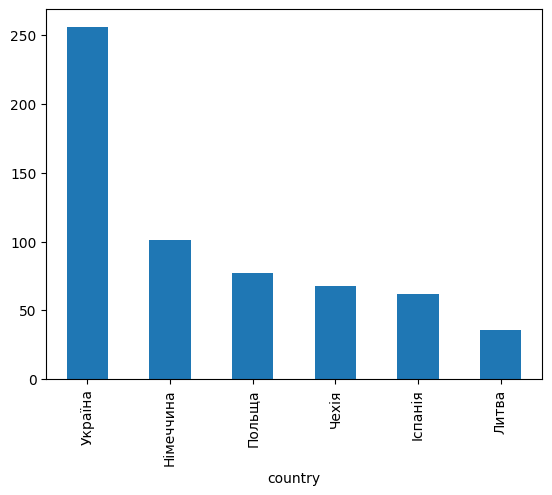

In [ ]:
# Завдання 51:
subs['country'].value_counts().plot(kind='bar')

plt.show()

**Завдання 52.** Побудуйте кругову діаграму (`pie`) розподілу підписників за тарифами.

> 💡 `value_counts().plot(kind="pie")`.

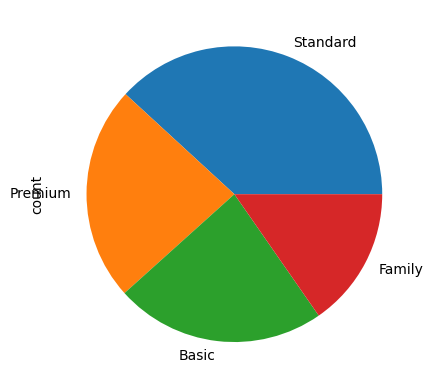

In [ ]:
# Завдання 52:
subs['plan'].value_counts().plot(kind='pie')
plt.show()

**Завдання 53.** Побудуйте гістограму розподілу віку підписників.

> 💡 `subs["age"].plot(kind="hist")`.

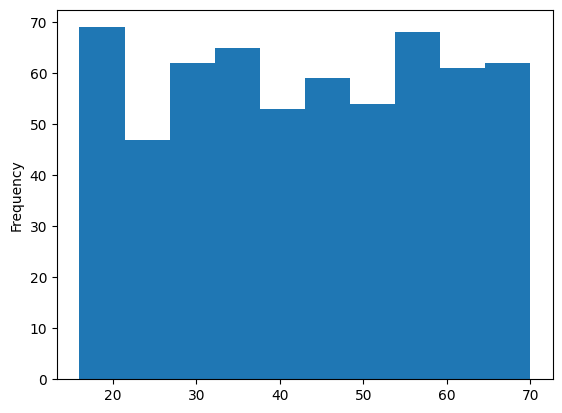

In [ ]:
# Завдання 53:
subs['age'].plot(kind='hist')
plt.show()

**Завдання 54.** Побудуйте гістограму тривалості сеансів з 20 інтервалами (bins).

> 💡 Параметр `bins=20`.

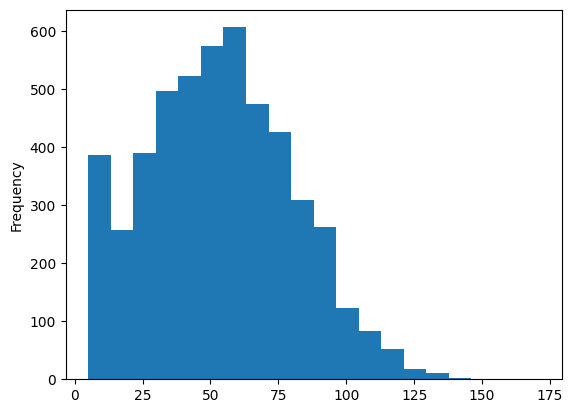

In [ ]:
# Завдання 54:
sess['duration_min'].plot(
    kind='hist',
    bins=20
)
plt.show()

**Завдання 55.** Побудуйте лінійну діаграму кількості сеансів по місяцях. Спочатку згрупуйте за місяцем, потім `.plot()`.

> 💡 `sess.groupby("month").size().plot()`.

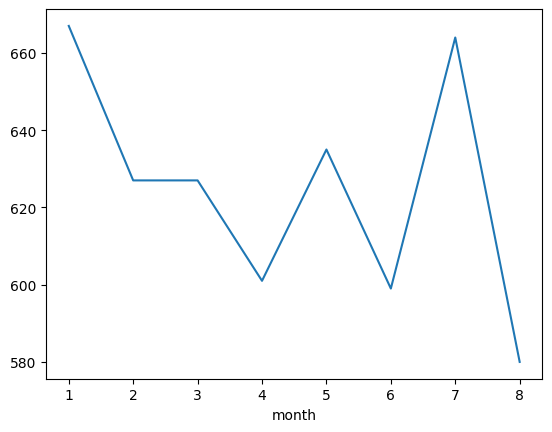

In [ ]:
# Завдання 55:
sess.groupby('month').size().plot(kind='line')
plt.show()


**Завдання 56.** Побудуйте горизонтальну стовпчасту діаграму кількості сеансів по жанрах.

> 💡 `kind="barh"`.

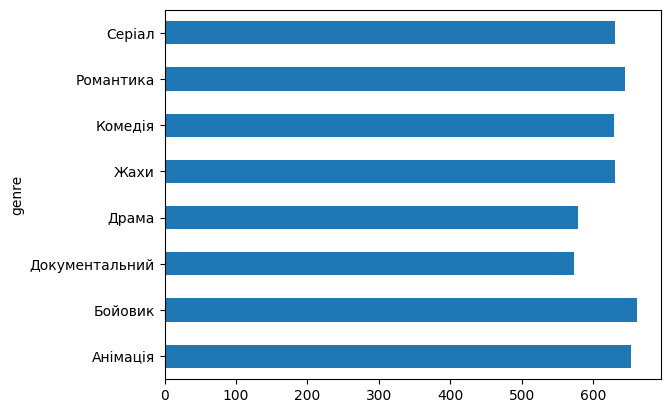

In [ ]:
# Завдання 56:
sess.groupby('genre').size().plot(kind='barh')
plt.show()

**Завдання 57.** Побудуйте стовпчасту діаграму середньої оцінки (`rating`) по жанрах.

> 💡 `groupby("genre")["rating"].mean().plot(kind="bar")`.

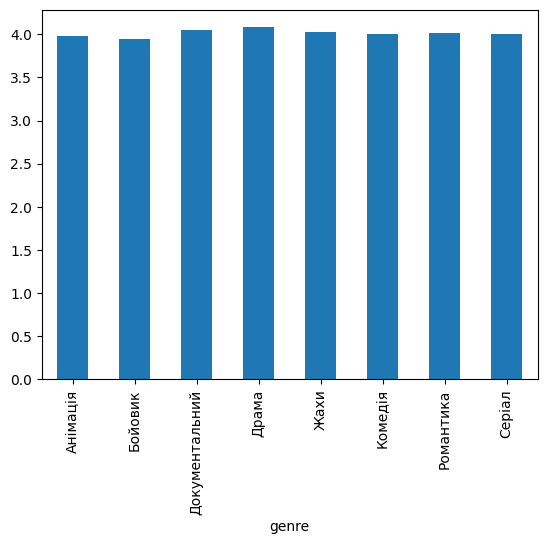

In [ ]:
# Завдання 57:
sess.groupby('genre')['rating'].mean().plot(kind='bar')
plt.show()

**Завдання 58.** Побудуйте scatter plot (точкову): по осі X — `duration_min`, по осі Y — `rating` (з таблиці `sess`).

> 💡 `sess.plot(kind="scatter", x="duration_min", y="rating")`.

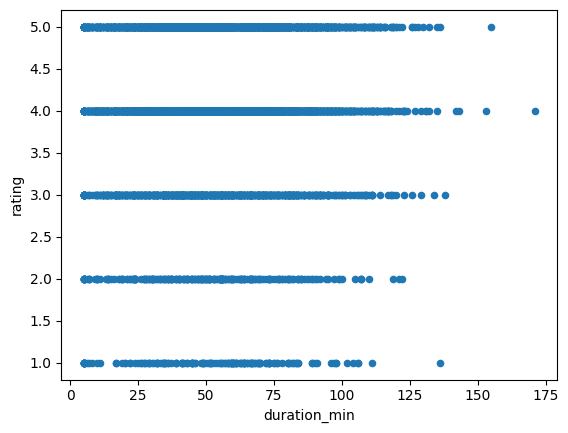

In [ ]:
# Завдання 58:
sess.plot(kind='scatter', x='duration_min', y='rating')
plt.show()

## Розділ 2.2. Основи matplotlib (завдання 59-66)

matplotlib дає більше контролю. Базовий синтаксис:

```python
plt.figure(figsize=(8, 5))   # розмір графіка
plt.bar(категорії, значення) # bar / line / scatter / hist
plt.title("Заголовок")
plt.xlabel("Назва X")
plt.ylabel("Назва Y")
plt.show()
```

Функції: `plt.bar()`, `plt.barh()`, `plt.plot()`, `plt.hist()`, `plt.scatter()`, `plt.pie()`.

**Завдання 59.** Створіть стовпчасту діаграму через `plt.bar()`. По осі X — країни, по осі Y — кількість підписників.

> 💡 Спочатку отримайте дані: `counts = subs["country"].value_counts()`. Потім: `plt.bar(counts.index, counts.values)`.

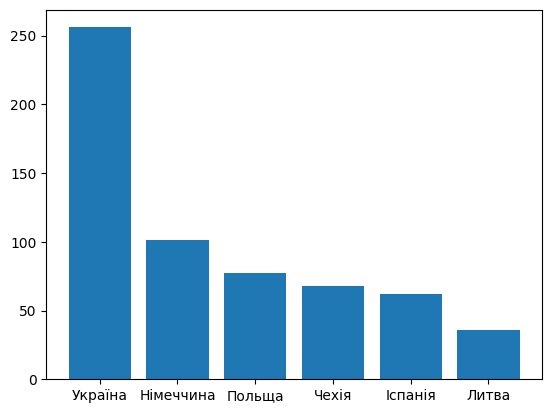

In [ ]:
# Завдання 59:
counts = subs['country'].value_counts()

plt.bar(counts.index, counts.values)
plt.show()

**Завдання 60.** Створіть лінійну діаграму через `plt.plot()`: динаміка кількості сеансів по місяцях.

> 💡 `monthly = sess.groupby("month").size()` + `plt.plot(monthly.index, monthly.values)`.

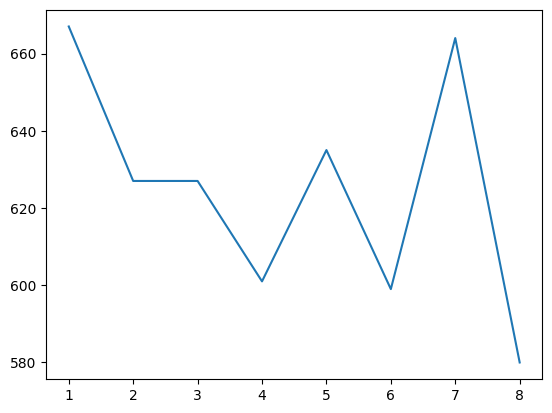

In [ ]:
# Завдання 60:
monthly = sess.groupby('month').size()
plt.plot(monthly.index, monthly.values)
plt.show()

**Завдання 61.** Створіть гістограму віку підписників через `plt.hist()` з 15 інтервалами.

> 💡 `plt.hist(subs["age"], bins=15)`.

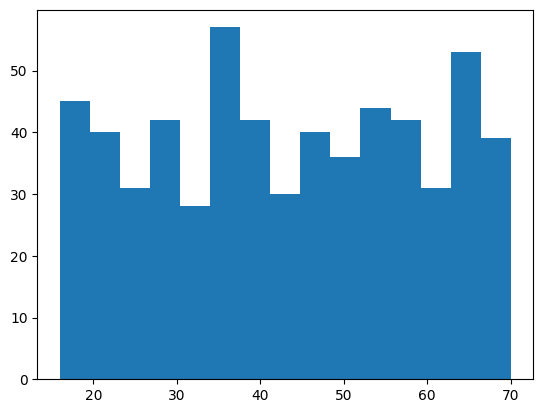

In [ ]:
# Завдання 61:
plt.hist(subs['age'], bins=15)
plt.show()

**Завдання 62.** Створіть точкову діаграму через `plt.scatter()`: вік підписників по X, місячна плата по Y.

> 💡 `plt.scatter(subs["age"], subs["monthly_fee"])`.

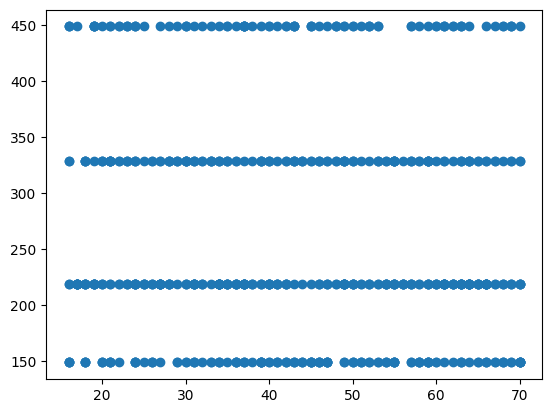

In [ ]:
# Завдання 62:
plt.scatter(subs['age'], subs['monthly_fee'])
plt.show()

**Завдання 63.** Створіть кругову діаграму через `plt.pie()`: розподіл сеансів за пристроями.

> 💡 `counts = sess["device"].value_counts()` + `plt.pie(counts.values, labels=counts.index)`.

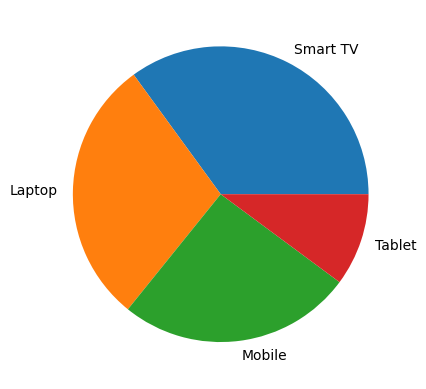

In [ ]:
# Завдання 63:
counts = sess['device'].value_counts()
plt.pie(counts.values, labels=counts.index)
plt.show()

**Завдання 64.** Побудуйте графік з розміром 10x6 дюймів через `plt.figure(figsize=...)`. Можна побудувати будь-який — наприклад, кількість сеансів по жанрах.

<BarContainer object of 8 artists>

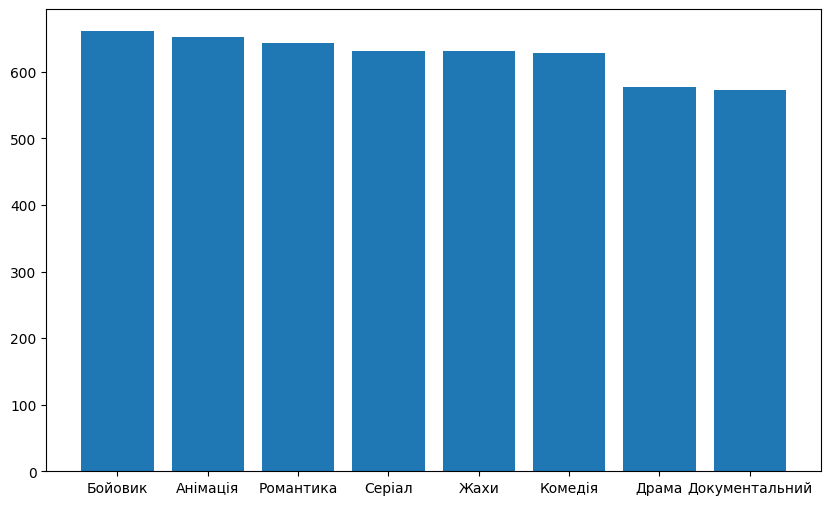

In [ ]:
# Завдання 64:
genre_counts = sess['genre'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(genre_counts.index, genre_counts.values)

**Завдання 65.** Побудуйте горизонтальну стовпчасту діаграму через `plt.barh()`: кількість сеансів по жанрах.

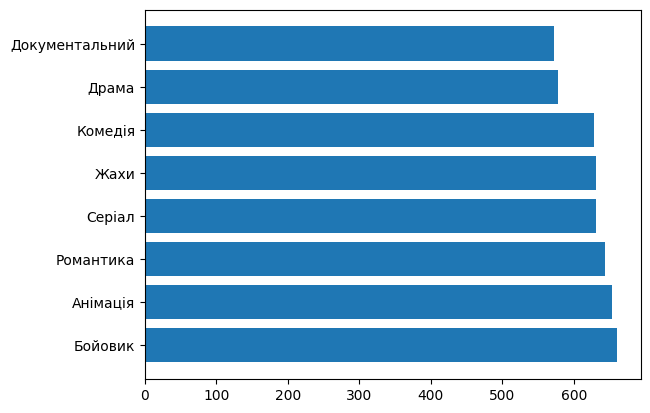

In [ ]:
# Завдання 65:
plt.barh(genre_counts.index, genre_counts.values)
plt.show()

**Завдання 66.** Побудуйте дві гістограми на одній фігурі (виклик `plt.hist` двічі підряд перед `plt.show()`): вік активних підписників та вік неактивних. Використайте параметр `alpha=0.5` для прозорості.

> 💡 `plt.hist(...активні..., alpha=0.5)` потім `plt.hist(...неактивні..., alpha=0.5)` потім `plt.show()`.

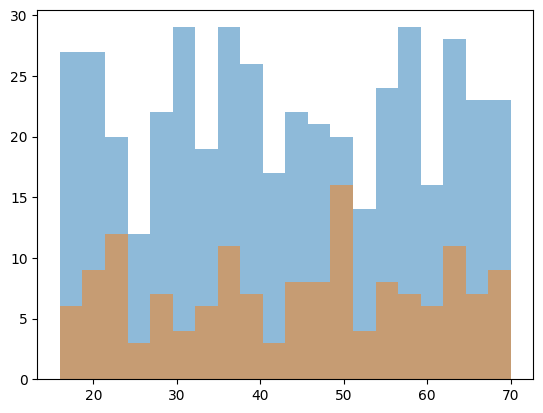

In [ ]:
# Завдання 66:
active = subs[subs['is_active']=='Так']
inactive = subs[subs['is_active']!='Так']

plt.hist(active['age'], alpha=0.5, bins=20)
plt.hist(inactive['age'], alpha=0.5, bins=20)

plt.show()

## Розділ 2.3. Налаштування графіків (завдання 67-74)

Тепер додаємо красу і інформативність:
- `plt.title("...")` — заголовок
- `plt.xlabel("...")`, `plt.ylabel("...")` — підписи осей
- `color="..."` — колір (`"red"`, `"#02C39A"`, `"teal"` тощо)
- `plt.xticks(rotation=45)` — повернути підписи по X
- `plt.grid(True)` — додати сітку
- `plt.figure(figsize=(w, h))` — розмір

**Завдання 67.** Побудуйте стовпчасту діаграму кількості підписників по країнах. Додайте заголовок "Кількість підписників по країнах", підпис осі X "Країна" та осі Y "Кількість".

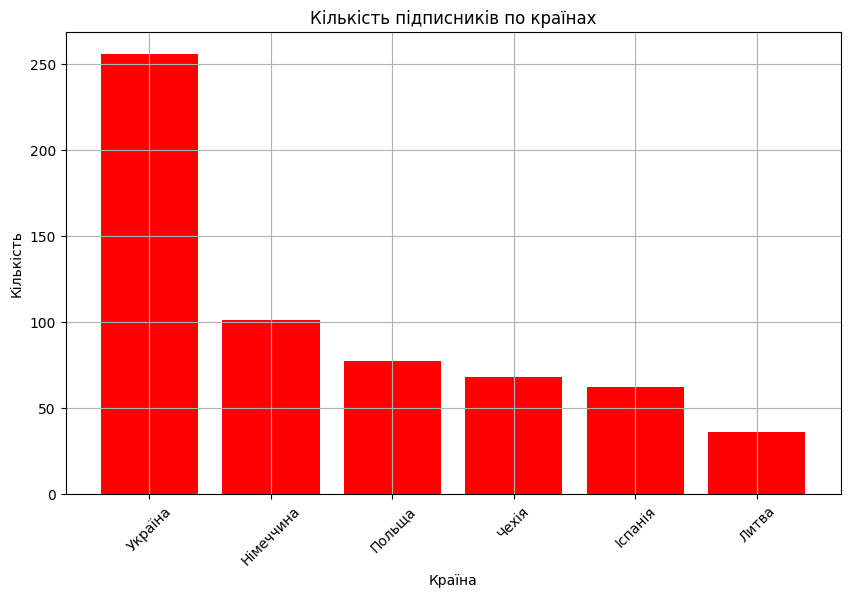

In [ ]:
# Завдання 67:
country_count = subs['country'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(country_count.index, country_count.values, color='red')

plt.title('Кількість підписників по країнах')
plt.xlabel('Країна')
plt.ylabel('Кількість')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

**Завдання 68.** Побудуйте графік середньої тривалості сеансу по жанрах. Усі стовпці зробіть КОЛЬОРОМ `teal`.

> 💡 Параметр `color="teal"` всередині `plt.bar()` або `.plot(kind="bar")`.

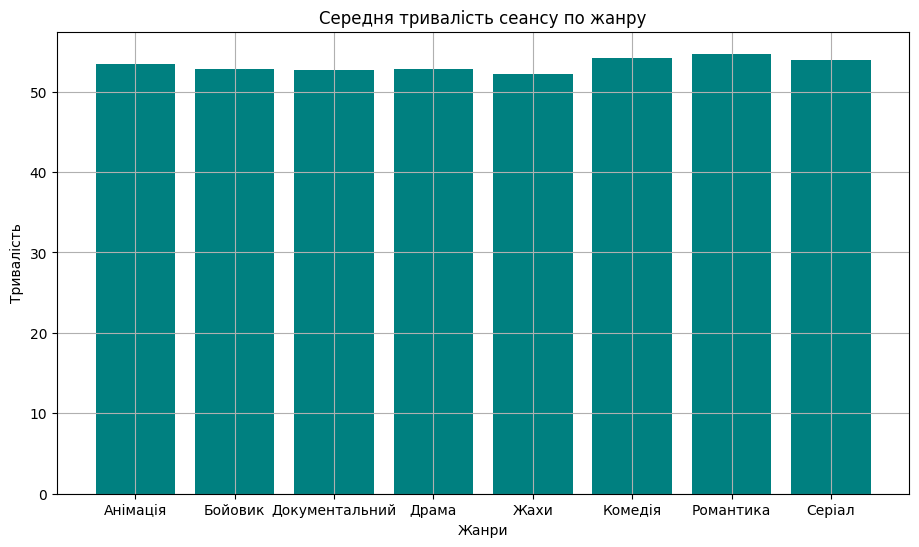

In [ ]:
# Завдання 68:
plt.figure(figsize=(11, 6))
avg_dur_genre = sess.groupby('genre')['duration_min'].mean().round(2)
plt.bar(avg_dur_genre.index, avg_dur_genre.values, color='teal')
plt.title('Середня тривалість сеансу по жанру')
plt.xlabel('Жанри')
plt.ylabel('Тривалість')
plt.grid(True)

plt.show()

**Завдання 69.** Побудуйте гістограму віку з 20 інтервалами. Колір — `"#02C39A"` (бірюзовий), додайте заголовок.

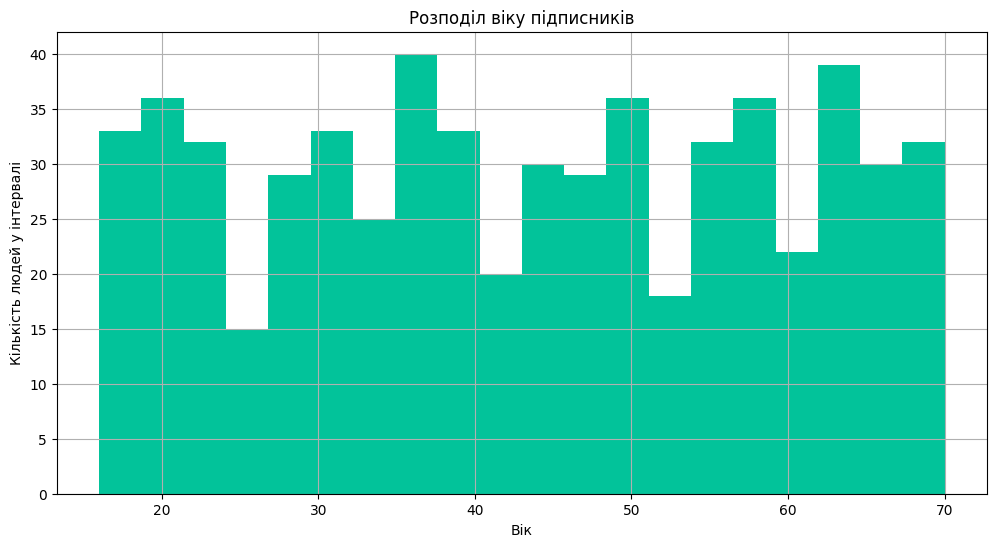

In [ ]:
# Завдання 69:
plt.figure(figsize=(12, 6))
plt.hist(subs['age'], bins=20, color="#02C39A")
plt.title('Розподіл віку підписників')
plt.xlabel('Вік')
plt.ylabel('Кількість людей у інтервалі')
plt.grid(True)

plt.show()

**Завдання 70.** Побудуйте діаграму кількості сеансів по місяцях. Підписи на осі X поверніть на 45 градусів.

> 💡 `plt.xticks(rotation=45)`.

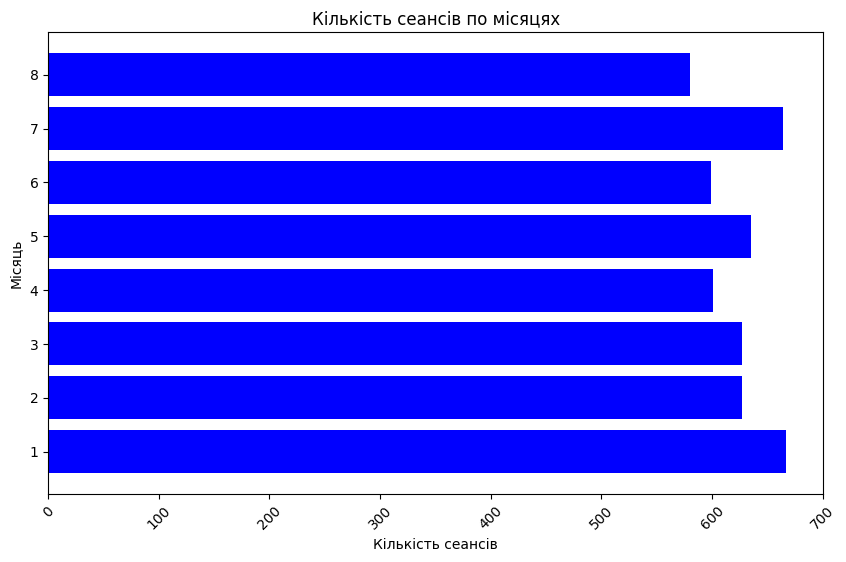

In [ ]:
# Завдання 70:
seans_count = sess['month'].value_counts()

plt.figure(figsize=(10, 6))
plt.barh(seans_count.index, seans_count.values, color='blue')
plt.title('Кількість сеансів по місяцях')
plt.ylabel('Місяць')
plt.xlabel('Кількість сеансів')
plt.xticks(rotation=45)

plt.show()

**Завдання 71.** Побудуйте стовпчасту діаграму середнього `monthly_fee` по тарифах. Розмір фігури 8x5. Додайте сітку.

> 💡 `plt.grid(True)`. Сітка для bar-діаграм виглядає краще тільки по осі Y: `plt.grid(axis="y")`.

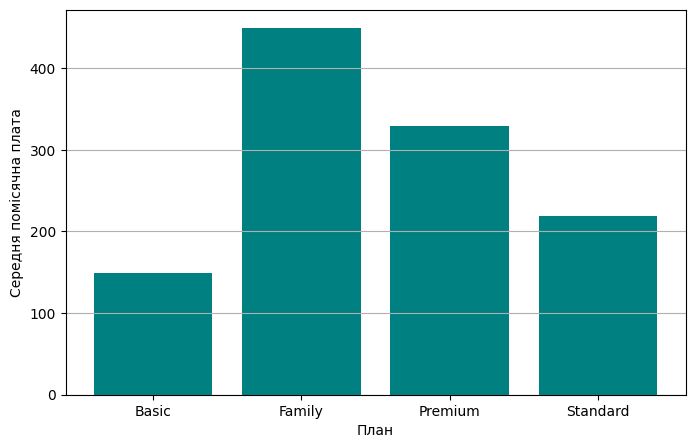

In [ ]:
# Завдання 71:
avg_month_fee = subs.groupby('plan')['monthly_fee'].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_month_fee.index, avg_month_fee.values, color='teal')
plt.grid(axis='y')
plt.xlabel('План')
plt.ylabel('Середня помісячна плата')

plt.show()

**Завдання 72.** Побудуйте лінійну діаграму кількості сеансів по місяцях. Тип лінії: пунктир, колір червоний, маркери у вигляді крапок.

> 💡 У `plt.plot()` параметри: `linestyle="--"`, `color="red"`, `marker="o"`. Або скорочено: `"r--o"`.

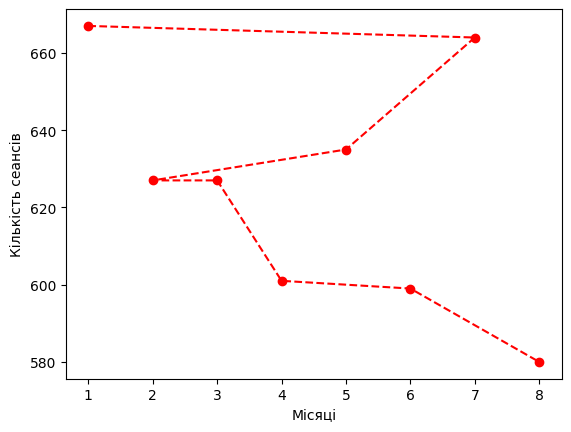

In [ ]:
# Завдання 72:
plt.plot(seans_count.index, seans_count.values, color='red', linestyle='--', marker='o')
plt.xlabel('Місяці')
plt.ylabel('Кількість сеансів')

plt.show()

**Завдання 73.** Побудуйте scatter plot: вік (X) vs місячна плата (Y). Колір точок зробіть напівпрозорим (`alpha=0.3`).

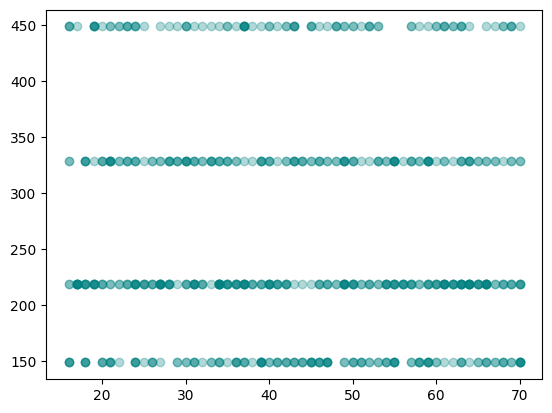

In [ ]:
# Завдання 73:
plt.scatter(subs['age'], subs['monthly_fee'], color='teal', alpha=0.3)

**Завдання 74.** Побудуйте кругову діаграму розподілу підписників за тарифами. Покажіть відсотки на кожному секторі.

> 💡 Параметр `autopct="%1.1f%%"` у `plt.pie()`.

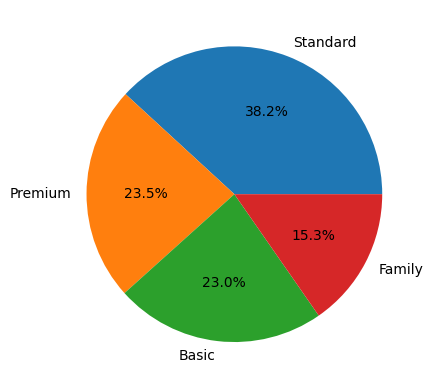

In [ ]:
# Завдання 74:
subs_tarif = subs['plan'].value_counts()

plt.pie(
    subs_tarif.values,
    labels=subs_tarif.index,
    autopct='%1.1f%%'
)

plt.show()

## Розділ 2.4. Легенди, кілька серій, subplots (завдання 75-80)

Кілька серій на одному графіку:
- Кожна серія має параметр `label="..."`
- Викликаємо `plt.legend()` — показуємо легенду

Кілька графіків поруч (subplots):
```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(...)
axes[0].set_title("Перший")
axes[1].plot(...)
axes[1].set_title("Другий")
plt.show()
```

**Завдання 75.** На одному графіку побудуйте дві лінії: кількість сеансів по місяцях для Smart TV та для Mobile. Додайте легенду з підписами.

> 💡 Двічі викличте `plt.plot(...)` з різними даними, кожен з параметром `label="..."`. Потім `plt.legend()`.

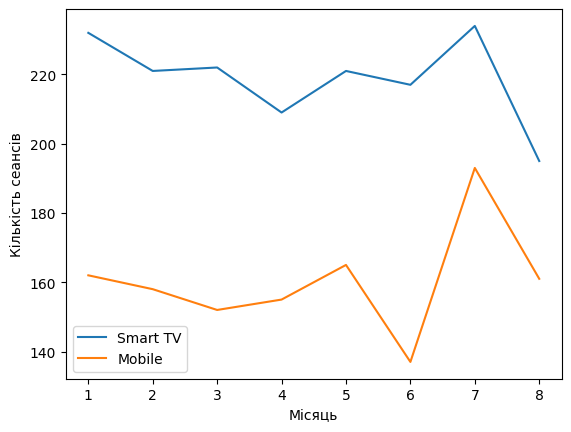

In [ ]:
# Завдання 75:
smart_tv = sess[sess['device']=='Smart TV'].groupby('month').size()
mobile = sess[sess['device']=='Mobile'].groupby('month').size()

plt.plot(smart_tv.index, smart_tv.values, label='Smart TV')
plt.plot(mobile.index, mobile.values, label='Mobile')

plt.legend()
plt.xlabel('Місяць')
plt.ylabel('Кількість сеансів')

plt.show()

**Завдання 76.** На одному графіку побудуйте дві гістограми віку: окремо для чоловіків і жінок (з прозорістю `alpha=0.5` та різними кольорами). Додайте легенду.

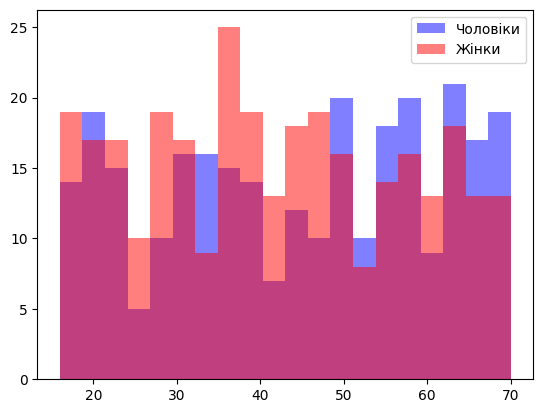

In [ ]:
# Завдання 76:
man = subs[subs['gender']=='Ч']['age']
woman = subs[subs['gender']=='Ж']['age']

plt.hist(man, bins=20, alpha=0.5, label='Чоловіки', color='blue')
plt.hist(woman, bins=20, alpha=0.5, label='Жінки', color='red')

plt.legend()
plt.show()

**Завдання 77.** Побудуйте дві стовпчасті діаграми поруч через `subplots(1, 2)`:
- зліва: кількість підписників по країнах
- справа: кількість підписників по тарифах

Кожній додайте заголовок.

Text(0.5, 1.0, 'Підписники по тарифах')

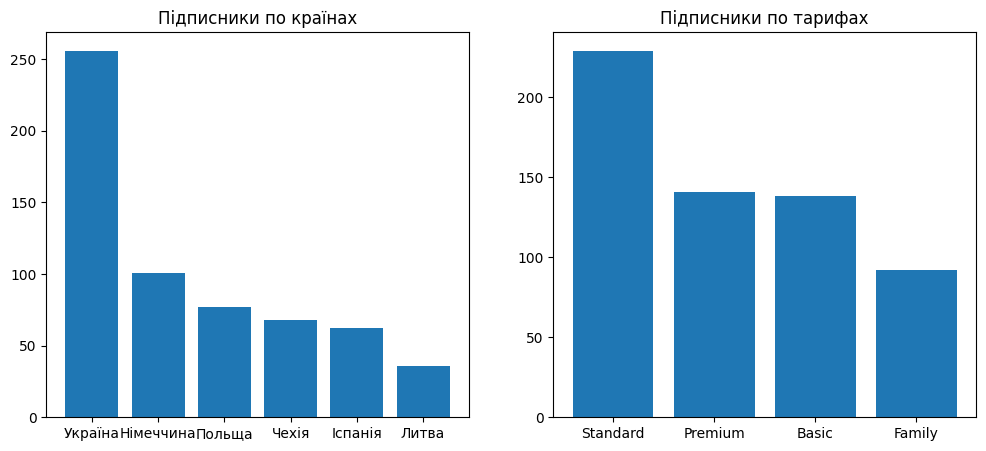

In [ ]:
# Завдання 77:
country_counts = subs['country'].value_counts()
plan_counts = subs['plan'].value_counts()

fix, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(country_counts.index, country_counts.values)
ax[0].set_title('Підписники по країнах')

ax[1].bar(plan_counts.index, plan_counts.values)
ax[1].set_title('Підписники по тарифах')



**Завдання 78.** Побудуйте 2x2 сітку графіків (`subplots(2, 2)`):
- (0,0): гістограма віку
- (0,1): кількість сеансів по жанрах (bar)
- (1,0): розподіл пристроїв (pie)
- (1,1): середня тривалість по жанрах (barh)

Кожному додайте заголовок. Розмір фігури — 12x10.

> 💡 `fig, axes = plt.subplots(2, 2, figsize=(12, 10))`. Доступ: `axes[0, 0]`, `axes[0, 1]`, `axes[1, 0]`, `axes[1, 1]`.

Text(0.5, 1.0, 'Середня тривалысть по жанрах')

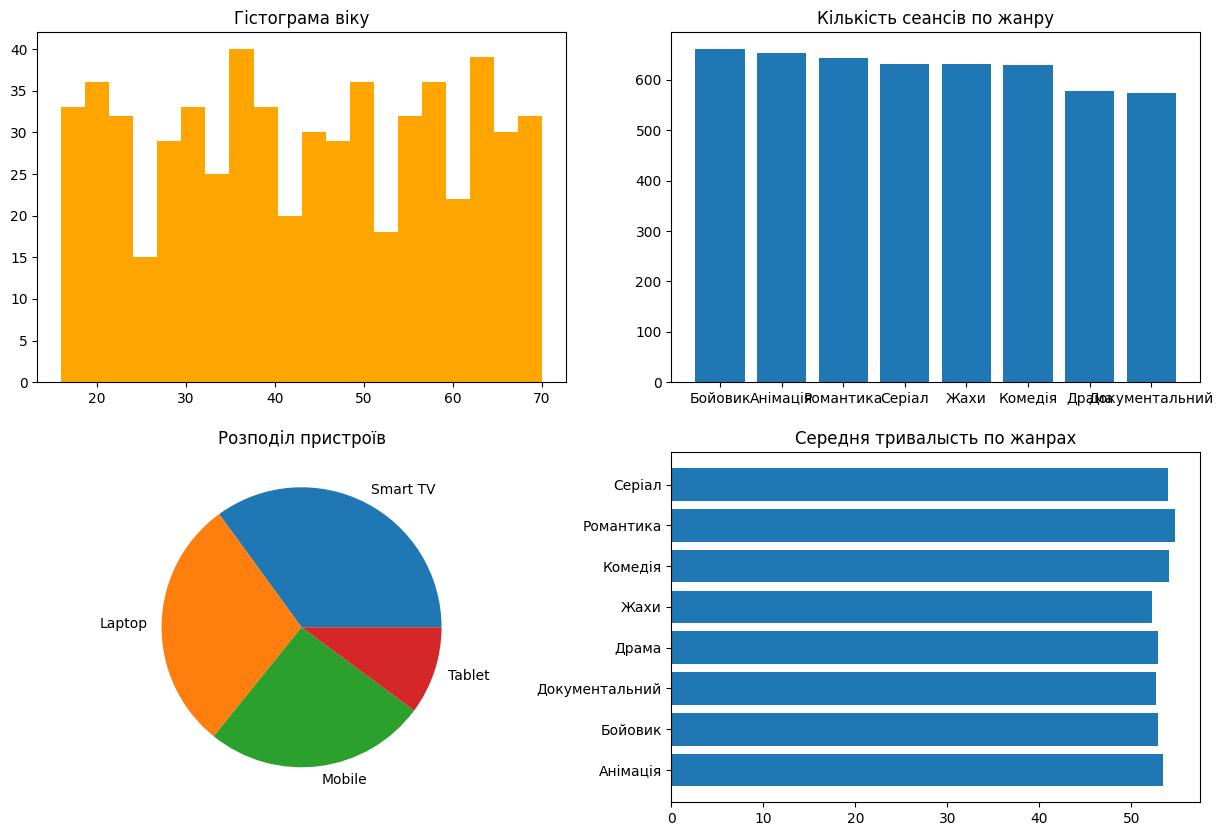

In [ ]:
# Завдання 78:
age = subs['age']
genre_counts = sess['genre'].value_counts()
device = sess['device'].value_counts()
avg_genre = sess.groupby('genre')['duration_min'].mean()

fix, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0, 0].hist(age, bins=20, color='orange')
ax[0, 0].set_title('Гістограма віку')

ax[0, 1].bar(genre_counts.index, genre_counts.values)
ax[0, 1].set_title('Кількість сеансів по жанру')

ax[1, 0].pie(device.values, labels=device.index)
ax[1, 0].set_title('Розподіл пристроїв')

ax[1, 1].barh(avg_genre.index, avg_genre.values)
ax[1, 1].set_title('Середня тривалысть по жанрах')

**Завдання 79.** Побудуйте графік середньої оцінки по жанрах. Стовпці пофарбуйте у РІЗНІ кольори (передайте список кольорів у параметр `color`).

> 💡 `color=["red","blue","green","orange","purple","teal","pink","gray"]` — стільки кольорів, скільки жанрів.

Text(0, 0.5, 'Середній рейтинг')

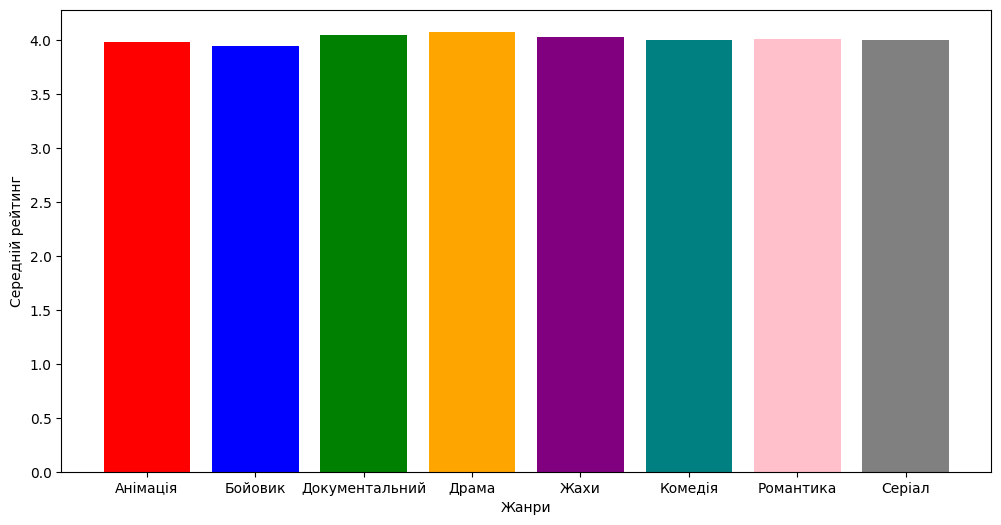

In [ ]:
# Завдання 79:
avg_rating_genre = sess.groupby('genre')['rating'].mean()
plt.figure(figsize=(12, 6))
plt.bar(avg_rating_genre.index, avg_rating_genre.values, color=['red', 'blue', 'green', 'orange','purple','teal','pink','gray'])
plt.xlabel('Жанри')
plt.ylabel('Середній рейтинг')

**Завдання 80.** Зробіть фінальний дашборд: 2x1 сітка (один графік над іншим), розмір 10x10.
- зверху: лінійна діаграма кількості сеансів по місяцях, з заголовком "Динаміка переглядів 2024"
- знизу: горизонтальна стовпчаста діаграма топ-10 жанрів за кількістю сеансів, з заголовком "Топ жанрів"

Після всього — `plt.tight_layout()` (виправляє накладання).

> 💡 `fig, axes = plt.subplots(2, 1, figsize=(10, 10))` + наприкінці `plt.tight_layout()`.

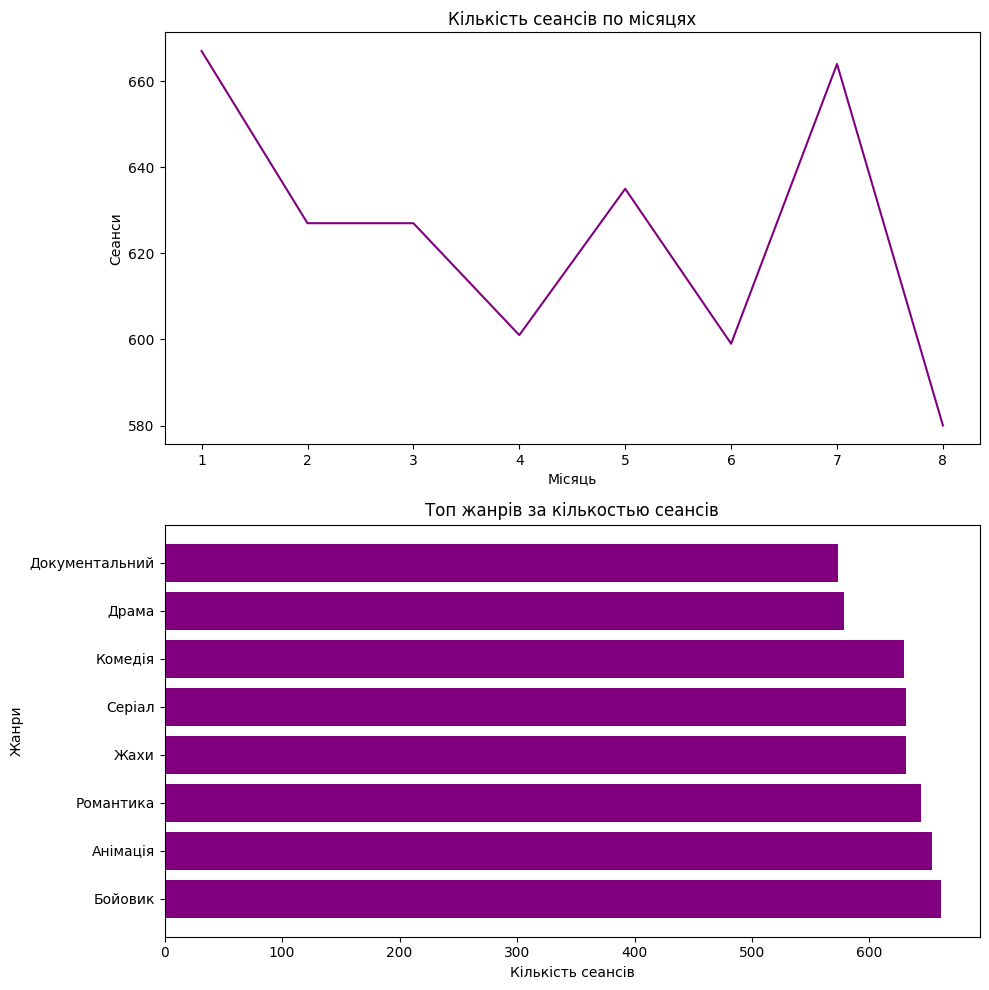

In [ ]:
# Завдання 80:
seans_month = sess['month'].value_counts().sort_index()
top_genre = sess.groupby('genre')['subscriber_id'].count().sort_values(ascending=False)

fix, ax = plt.subplots(2, 1, figsize=(10, 10))

ax[0].plot(seans_month.index, seans_month.values, color='purple')
ax[0].set_title('Кількість сеансів по місяцях')
ax[0].set_xlabel('Місяць')
ax[0].set_ylabel('Сеанси')

ax[1].barh(top_genre.index, top_genre.values, color='purple')
ax[1].set_title('Топ жанрів за кількостью сеансів')
ax[1].set_xlabel('Кількість сеансів')
ax[1].set_ylabel('Жанри')

plt.tight_layout()

---

# 🎉 Готово!

Якщо ви виконали всі 80 завдань — вітаємо! Ви відпрацювали:

**Pandas (50 завдань):**
- ✅ `loc` та `iloc` — потужна вибірка за позицією та умовою
- ✅ Складніший `groupby` з `.agg()`, `.transform()`, групування за кількома стовпцями
- ✅ `pivot_table` — зведені таблиці у стилі Excel
- ✅ Робота з датами (`.dt.month`, `.dt.day_name`, різниця дат)
- ✅ Об'єднання таблиць через `merge`

**Matplotlib (30 завдань):**
- ✅ Швидкі графіки через pandas `.plot()`
- ✅ Базові функції matplotlib: `bar`, `plot`, `hist`, `scatter`, `pie`
- ✅ Налаштування: заголовки, осі, кольори, сітка
- ✅ Легенди та кілька серій на одному графіку
- ✅ Subplots — кілька графіків поруч

### Порада
Найкращий спосіб запам'ятати — повернутись через тиждень і спробувати найскладніші завдання знову, не підглядаючи. **Так тримати! 🐼📊**
